# WP3 — Part 6: CLS Token + Augmentation (K random masks)

**Idea:** combine the two previous improvements:
- **CLS token** (wp3_4): use `last_hidden_state[:, 0]` instead of the mean of patches → slight improvement (+0.003)
- **Augmentation** (wp3_5): K=5 random masks per image → significant gain (+0.043)

| Config | Representation | Train pairs | val_cos |
|--------|---------------|-------------|--------|
| wp3_2 baseline | z_full (no mask) | 117k | 0.8894 |
| wp3_3 v2 | z_full (no mask) | 117k | 0.8898 |
| wp3_4 v2 | z_cls (no mask) | 117k | 0.8929 |
| wp3_5 baseline | z_full aug K=5 | 585k | 0.9319 |
| wp3_5 v2 | z_full aug K=5 | 585k | 0.9306 |
| **this notebook** | **z_cls aug K=5** | **585k** | **?** |

**Pipeline:**

1. **Input image** → resize 256, center crop 224
2. **MAE encoder** → 75% random masking, repeated K=5 times → `last_hidden_state[:, 0]` = `z_cls_masked` *(1024-d)*
3. **CLIP encoder** → full image → `z_clip` *(768-d)*, L2-normalized *(frozen, not trained)*
4. **Projection MLP** → `z_cls_masked` → `z_proj` *(768-d)*, L2-normalized
5. **Objective** → minimize `1 − cos(z_proj, z_clip)`

## 6.1 Loading MAE and CLIP

In [2]:
import os
import torch
import torch.nn.functional as F
from transformers import ViTImageProcessor, ViTMAEModel, CLIPProcessor, CLIPModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

MAE_PATH  = './vit-mae-large' if os.path.exists('./vit-mae-large') else 'facebook/vit-mae-large'
CLIP_PATH = './clip-vit-large-patch14' if os.path.exists('./clip-vit-large-patch14') else 'openai/clip-vit-large-patch14'

mae_processor = ViTImageProcessor.from_pretrained(MAE_PATH)
mae_encoder  = ViTMAEModel.from_pretrained(MAE_PATH).to(DEVICE)
mae_encoder.eval()

clip_model = CLIPModel.from_pretrained(CLIP_PATH).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
clip_model.eval()

MAE_DIM  = mae_encoder.config.hidden_size
CLIP_DIM = clip_model.config.projection_dim
print(f'MAE dim  : {MAE_DIM}')
print(f'CLIP dim : {CLIP_DIM}')
print(f'MAE mask_ratio natif : {mae_encoder.config.mask_ratio}')
print(f'→ {int(196 * (1 - mae_encoder.config.mask_ratio))} patches visibles sur 196')

Device : cpu
MAE dim  : 1024
CLIP dim : 768
MAE mask_ratio natif : 0.75
→ 49 patches visibles sur 196


## 6.2 Dataset loading

In [2]:
from datasets import load_dataset
from torch.utils.data import Dataset
from torchvision import transforms
from huggingface_hub import snapshot_download

DATASET_DIR = './imagenet100-hf'
if not os.path.exists(f'{DATASET_DIR}/data'):
    snapshot_download(repo_id='ilee0022/ImageNet100', repo_type='dataset', local_dir=DATASET_DIR)

transform_tensor = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

class ImageNet100Dataset(Dataset):
    def __init__(self, split, transform=None):
        pattern = f'{DATASET_DIR}/data/{split}-*.parquet'
        self.ds = load_dataset('parquet', data_files={split: pattern})[split]
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img   = self.ds[idx]['image'].convert('RGB')
        label = self.ds[idx]['label']
        if self.transform:
            img = self.transform(img)
        return img, label

dataset_train = ImageNet100Dataset('train',      transform=transform_tensor)
dataset_val   = ImageNet100Dataset('validation', transform=transform_tensor)
print(f'Train : {len(dataset_train)} images')
print(f'Val   : {len(dataset_val)} images')

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

Train : 117000 images
Val   : 13000 images


## 6.3 Pair generation (z_cls_masked, z_clip)

Only change from `wp3_5`: we take `last_hidden_state[:, 0]` (CLS token) instead of `last_hidden_state[:, 1:].mean(dim=1)` (mean of visible patches).

- **Train**: K=5 random masks → 585,000 pairs
- **Val**: fixed mask per batch (reproducible)

In [3]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

K_AUGMENT = 5


def generate_pairs_cls_aug(dataset, batch_size=64, K=5, val_mode=False, desc=''):
    """
    Génère K paires (z_cls_masked, z_clip) par image.
    z_cls_masked = CLS token de MAE avec masquage 75%.
    z_clip       = embedding CLIP image complète, L2-normalisé.
    val_mode     = masque déterministe, K forcé à 1.
    """
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=(DEVICE == 'cuda'),
    )

    all_z_cls, all_z_clip, all_labels = [], [], []
    n_passes = 1 if val_mode else K

    for batch_idx, (images, labels) in enumerate(tqdm(loader, desc=desc)):
        B = images.shape[0]

        # CLIP : une seule passe par batch (image complète)
        clip_inputs = clip_processor(
            images=list(images), return_tensors='pt', do_rescale=False
        )
        clip_inputs = {k: v.to(DEVICE) for k, v in clip_inputs.items()}
        with torch.no_grad():
            vision_out = clip_model.vision_model(**clip_inputs)
            z_clip = clip_model.visual_projection(vision_out.pooler_output)
        z_clip = F.normalize(z_clip, dim=-1).cpu()  # (B, 768)

        mae_inputs = mae_processor(
            images=list(images), return_tensors='pt', do_rescale=False
        )
        mae_inputs = {k: v.to(DEVICE) for k, v in mae_inputs.items()}

        # MAE : n_passes fois avec masques différents
        for k in range(n_passes):
            if val_mode:
                g = torch.Generator()
                g.manual_seed(batch_idx)
                noise = torch.rand(B, 196, generator=g).to(DEVICE)
            else:
                noise = torch.rand(B, 196).to(DEVICE)

            with torch.no_grad():
                out = mae_encoder(**mae_inputs, noise=noise)

            # CLS token uniquement : last_hidden_state[:, 0]
            z_cls_k = out.last_hidden_state[:, 0].cpu()  # (B, 1024)

            all_z_cls.append(z_cls_k)
            all_z_clip.append(z_clip)
            all_labels.append(labels)

    return {
        'z_cls':   torch.cat(all_z_cls),
        'z_clip':  torch.cat(all_z_clip),
        'labels':  torch.cat(all_labels),
    }

In [4]:
train_file = f'pairs_cls_aug_K{K_AUGMENT}_train.pt'
val_file   = f'pairs_cls_aug_K{K_AUGMENT}_val.pt'

if os.path.exists(train_file) and os.path.exists(val_file):
    print('Fichiers déjà existants, chargement...')
    data_train = torch.load(train_file, weights_only=False)
    data_val   = torch.load(val_file,   weights_only=False)
else:
    print(f'Génération train K={K_AUGMENT} → {117000 * K_AUGMENT:,} paires attendues')
    data_train = generate_pairs_cls_aug(
        dataset_train, batch_size=64, K=K_AUGMENT, val_mode=False, desc='Train'
    )
    print('Génération val (masque fixe, K=1)')
    data_val = generate_pairs_cls_aug(
        dataset_val, batch_size=64, K=1, val_mode=True, desc='Val'
    )
    torch.save(data_train, train_file)
    torch.save(data_val,   val_file)

print(f'Train z_cls : {data_train["z_cls"].shape}')
print(f'Val   z_cls : {data_val["z_cls"].shape}')

del mae_encoder, clip_model
torch.cuda.empty_cache()
print('VRAM libérée')

Fichiers déjà existants, chargement...
Train z_cls : torch.Size([585000, 1024])
Val   z_cls : torch.Size([13000, 1024])
VRAM libérée


---
## 6.4 Training — MLP baseline (z_cls_masked → z_clip)

In [5]:
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
K_AUGMENT = 5

data_train = torch.load(f'pairs_cls_aug_K{K_AUGMENT}_train.pt', weights_only=False)
data_val   = torch.load(f'pairs_cls_aug_K{K_AUGMENT}_val.pt',   weights_only=False)

train_ds = TensorDataset(data_train['z_cls'], data_train['z_clip'])
val_ds   = TensorDataset(data_val['z_cls'],   data_val['z_clip'])

BATCH_SIZE   = 512
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_ds):,} paires  (×{K_AUGMENT} vs baseline)')
print(f'Val   : {len(val_ds):,} paires')

Train : 585,000 paires  (×5 vs baseline)
Val   : 13,000 paires


In [6]:
class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


def projection_loss(z_proj, z_clip):
    return (1 - F.cosine_similarity(z_proj, z_clip)).mean()


def eval_epoch(loader, model):
    model.eval()
    total_loss, total_cos, n = 0., 0., 0
    with torch.no_grad():
        for z_in, z_clip in loader:
            z_in, z_clip = z_in.to(DEVICE), z_clip.to(DEVICE)
            z_proj = model(z_in)
            B = z_in.shape[0]
            total_loss += projection_loss(z_proj, z_clip).item() * B
            total_cos  += F.cosine_similarity(z_proj, z_clip).mean().item() * B
            n += B
    return total_loss / n, total_cos / n


model = ProjectionMLP().to(DEVICE)
print(f'Paramètres : {sum(p.numel() for p in model.parameters()):,}')

Paramètres : 1,838,848


In [7]:
N_EPOCHS  = 100
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history   = {'train_loss': [], 'val_loss': [], 'val_cos_sim': []}
best_cos, best_epoch = 0., 0

for epoch in range(N_EPOCHS):
    model.train()
    total_loss, n = 0., 0
    for z_in, z_clip in train_loader:
        z_in, z_clip = z_in.to(DEVICE), z_clip.to(DEVICE)
        optimizer.zero_grad()
        loss = projection_loss(model(z_in), z_clip)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * z_in.shape[0]
        n += z_in.shape[0]
    scheduler.step()

    train_loss = total_loss / n
    val_loss, val_cos = eval_epoch(val_loader, model)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cos_sim'].append(val_cos)

    if val_cos > best_cos:
        best_cos, best_epoch = val_cos, epoch + 1
        torch.save(model.state_dict(), 'projection_cls_aug_mlp_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | cos={val_cos:.4f}')

print(f'Meilleur modèle : epoch {best_epoch}, val_cos={best_cos:.4f}')
print(f'Référence aug K=5 baseline (wp3_5) : 0.9319')
best_cos_baseline = best_cos

Epoch  10/100 | train=0.0609 | val=0.0664 | cos=0.9336
Epoch  20/100 | train=0.0585 | val=0.0657 | cos=0.9343
Epoch  30/100 | train=0.0574 | val=0.0658 | cos=0.9342
Epoch  40/100 | train=0.0566 | val=0.0656 | cos=0.9344
Epoch  50/100 | train=0.0561 | val=0.0656 | cos=0.9344
Epoch  60/100 | train=0.0556 | val=0.0656 | cos=0.9344
Epoch  70/100 | train=0.0552 | val=0.0655 | cos=0.9345
Epoch  80/100 | train=0.0549 | val=0.0655 | cos=0.9345
Epoch  90/100 | train=0.0547 | val=0.0655 | cos=0.9345
Epoch 100/100 | train=0.0546 | val=0.0655 | cos=0.9345
Meilleur modèle : epoch 88, val_cos=0.9345
Référence aug K=5 baseline (wp3_5) : 0.9319


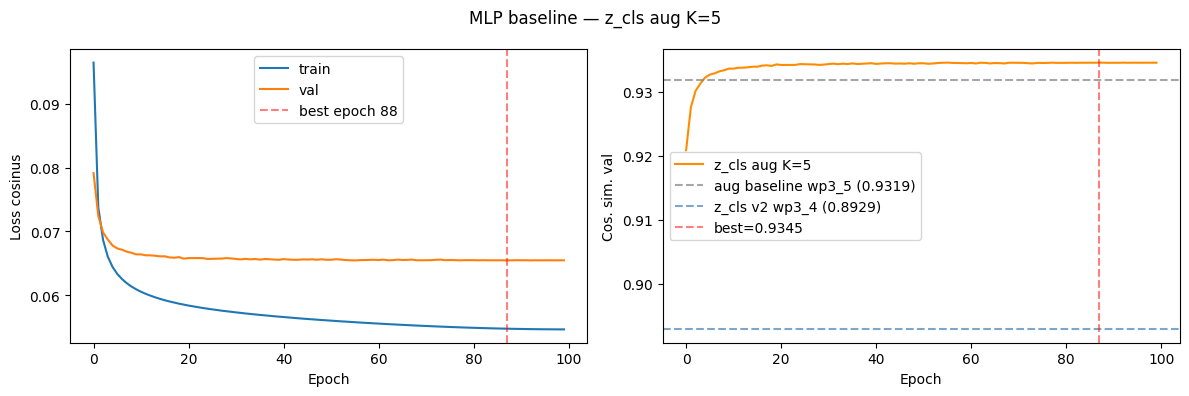

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'MLP baseline — z_cls aug K={K_AUGMENT}')

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best epoch {best_epoch}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss cosinus'); axes[0].legend()

axes[1].plot(history['val_cos_sim'], color='darkorange', label=f'z_cls aug K={K_AUGMENT}')
axes[1].axhline(0.9319, color='gray',     linestyle='--', alpha=0.7, label='aug baseline wp3_5 (0.9319)')
axes[1].axhline(0.8929, color='steelblue',linestyle='--', alpha=0.7, label='z_cls v2 wp3_4 (0.8929)')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best={best_cos:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cos. sim. val'); axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6.5 Training — Improved MLP (BatchNorm + Dropout + early stopping)

In [9]:
z_mean = data_train['z_cls'].mean(dim=0)
z_std  = data_train['z_cls'].std(dim=0).clamp(min=1e-6)

z_train_norm = (data_train['z_cls'] - z_mean) / z_std
z_val_norm   = (data_val['z_cls']   - z_mean) / z_std

torch.save({'mean': z_mean, 'std': z_std}, f'z_cls_aug_K{K_AUGMENT}_norm_stats.pt')

print(f'z_cls avant normalisation — mean: {data_train["z_cls"].mean():.4f}, std: {data_train["z_cls"].std():.4f}')
print(f'z_cls après normalisation — mean: {z_train_norm.mean():.4f}, std: {z_train_norm.std():.4f}')

train_ds_v2 = TensorDataset(z_train_norm, data_train['z_clip'])
val_ds_v2   = TensorDataset(z_val_norm,   data_val['z_clip'])
train_loader_v2 = DataLoader(train_ds_v2, batch_size=512, shuffle=True,  num_workers=0)
val_loader_v2   = DataLoader(val_ds_v2,   batch_size=512, shuffle=False, num_workers=0)
print(f'Train normalisé : {len(train_ds_v2):,} paires')

z_cls avant normalisation — mean: -0.0076, std: 0.2902
z_cls après normalisation — mean: -0.0000, std: 1.0000
Train normalisé : 585,000 paires


In [10]:
class ProjectionMLPv2(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


model_v2 = ProjectionMLPv2().to(DEVICE)
print(f'Paramètres : {sum(p.numel() for p in model_v2.parameters()):,}')

Paramètres : 1,840,896


In [11]:
N_EPOCHS  = 200
PATIENCE  = 25
optimizer = AdamW(model_v2.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history_v2 = {'train_loss': [], 'val_loss': [], 'val_cos_sim': []}
best_cos_v2, best_epoch_v2, patience_counter = 0., 0, 0

for epoch in range(N_EPOCHS):
    model_v2.train()
    total_loss, n = 0., 0
    for z_in, z_clip in train_loader_v2:
        z_in, z_clip = z_in.to(DEVICE), z_clip.to(DEVICE)
        optimizer.zero_grad()
        loss = projection_loss(model_v2(z_in), z_clip)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * z_in.shape[0]
        n += z_in.shape[0]
    scheduler.step()

    train_loss = total_loss / n
    val_loss, val_cos = eval_epoch(val_loader_v2, model_v2)
    history_v2['train_loss'].append(train_loss)
    history_v2['val_loss'].append(val_loss)
    history_v2['val_cos_sim'].append(val_cos)

    if val_cos > best_cos_v2:
        best_cos_v2, best_epoch_v2, patience_counter = val_cos, epoch + 1, 0
        torch.save(model_v2.state_dict(), 'projection_cls_aug_mlpv2_best.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | cos={val_cos:.4f} | patience={patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping à l epoch {epoch + 1}')
        break

print(f'Meilleur modèle : epoch {best_epoch_v2}, val_cos={best_cos_v2:.4f}')
best_cos_v2_cls_aug = best_cos_v2

Epoch  20/200 | train=0.0657 | val=0.0673 | cos=0.9327 | patience=0/25
Epoch  40/200 | train=0.0643 | val=0.0670 | cos=0.9330 | patience=0/25
Epoch  60/200 | train=0.0636 | val=0.0670 | cos=0.9330 | patience=1/25
Epoch  80/200 | train=0.0631 | val=0.0671 | cos=0.9329 | patience=16/25
Epoch 100/200 | train=0.0628 | val=0.0670 | cos=0.9330 | patience=11/25
Epoch 120/200 | train=0.0625 | val=0.0670 | cos=0.9330 | patience=19/25
Epoch 140/200 | train=0.0622 | val=0.0670 | cos=0.9330 | patience=0/25
Epoch 160/200 | train=0.0621 | val=0.0670 | cos=0.9330 | patience=13/25
Early stopping à l epoch 172
Meilleur modèle : epoch 147, val_cos=0.9331


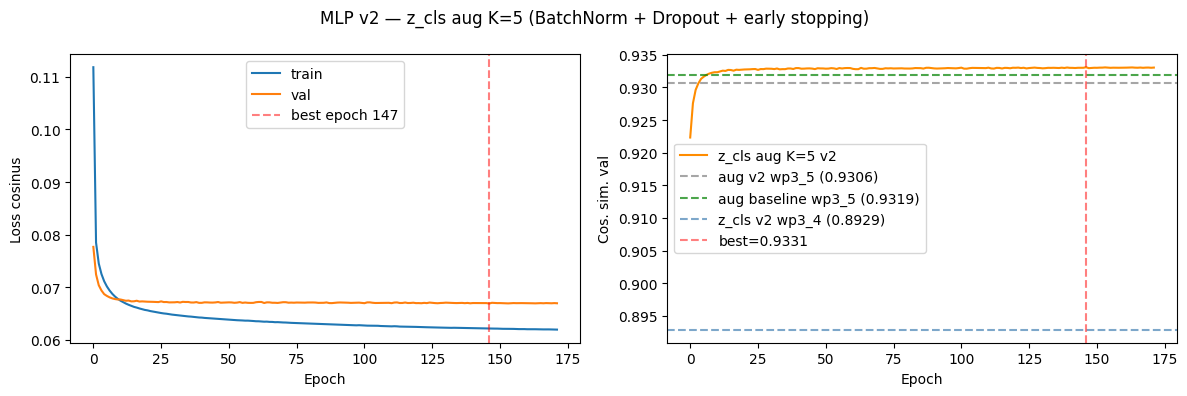

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'MLP v2 — z_cls aug K={K_AUGMENT} (BatchNorm + Dropout + early stopping)')

axes[0].plot(history_v2['train_loss'], label='train')
axes[0].plot(history_v2['val_loss'],   label='val')
axes[0].axvline(best_epoch_v2 - 1, color='red', linestyle='--', alpha=0.5, label=f'best epoch {best_epoch_v2}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss cosinus'); axes[0].legend()

axes[1].plot(history_v2['val_cos_sim'], color='darkorange', label=f'z_cls aug K={K_AUGMENT} v2')
axes[1].axhline(0.9306, color='gray',      linestyle='--', alpha=0.7, label='aug v2 wp3_5 (0.9306)')
axes[1].axhline(0.9319, color='green',     linestyle='--', alpha=0.7, label='aug baseline wp3_5 (0.9319)')
axes[1].axhline(0.8929, color='steelblue', linestyle='--', alpha=0.7, label='z_cls v2 wp3_4 (0.8929)')
axes[1].axvline(best_epoch_v2 - 1, color='red', linestyle='--', alpha=0.5, label=f'best={best_cos_v2:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cos. sim. val'); axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6.6 Full comparative summary

In [9]:
print('=' * 60)
print('Bilan — val cosine similarity')
print('=' * 60)
print(f'z_full  baseline  (117k,  wp3_2)        : 0.8894')
print(f'z_full  v2        (117k,  wp3_3)        : 0.8898')
print(f'z_cls   v2        (117k,  wp3_4)        : 0.8929')
print(f'z_full  aug K=5 baseline (585k, wp3_5)  : 0.9319')
print(f'z_full  aug K=5 v2       (585k, wp3_5)  : 0.9306')
print(f'z_cls   aug K=5 baseline (585k, wp3_6)  : 0.9345')
print(f'z_cls   aug K=5 v2       (585k, wp3_6)  : 0.9331')
print('=' * 60)

Bilan — val cosine similarity
z_full  baseline  (117k,  wp3_2)        : 0.8894
z_full  v2        (117k,  wp3_3)        : 0.8898
z_cls   v2        (117k,  wp3_4)        : 0.8929
z_full  aug K=5 baseline (585k, wp3_5)  : 0.9319
z_full  aug K=5 v2       (585k, wp3_5)  : 0.9306
z_cls   aug K=5 baseline (585k, wp3_6)  : 0.9345
z_cls   aug K=5 v2       (585k, wp3_6)  : 0.9331


---
## 6.7 Zero-shot test (z_cls aug v2)

In [ ]:
import json
from transformers import CLIPProcessor, CLIPModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

try:
    clip_model
    print('CLIP déjà en mémoire')
except NameError:
    CLIP_PATH = './clip-vit-large-patch14' if os.path.exists('./clip-vit-large-patch14') else 'openai/clip-vit-large-patch14'
    clip_model     = CLIPModel.from_pretrained(CLIP_PATH).to(DEVICE)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
    clip_model.eval()
    print('CLIP rechargé')

model_v2.load_state_dict(torch.load('projection_cls_aug_mlpv2_best.pt', map_location=DEVICE))
model_v2.eval()

norm_stats = torch.load(f'z_cls_aug_K{K_AUGMENT}_norm_stats.pt', weights_only=False)
z_mean = norm_stats['mean']
z_std  = norm_stats['std']

with open('imagenet100-hf/label2text.json') as f:
    label2text = json.load(f)
CONCEPTS = [f'a photo of a {name}' for name in label2text.values()]

text_inputs = clip_processor(text=CONCEPTS, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad():
    text_out      = clip_model.text_model(**text_inputs)
    text_features = clip_model.text_projection(text_out.pooler_output)
text_features = F.normalize(text_features.float(), dim=-1)

N_SAMPLES = 10
z_cls_samples  = data_val['z_cls'][:N_SAMPLES]
z_clip_samples = data_val['z_clip'][:N_SAMPLES]
labels_samples = data_val['labels'][:N_SAMPLES]

z_norm = (z_cls_samples - z_mean) / z_std
with torch.no_grad():
    z_proj = model_v2(z_norm.to(DEVICE))

sims_proj = z_proj @ text_features.T
sims_clip = z_clip_samples.to(DEVICE) @ text_features.T

TOP_K = 3
correct_top1 = 0
print(f'\n{"="*60}')
for i in range(N_SAMPLES):
    true_idx   = labels_samples[i].item()
    true_name  = label2text[str(true_idx)]
    top_proj   = sims_proj[i].topk(TOP_K).indices.tolist()
    top_clip   = sims_clip[i].topk(TOP_K).indices.tolist()
    pred_names = [label2text[str(j)] for j in top_proj]
    ora_names  = [label2text[str(j)] for j in top_clip]
    match      = (true_idx == top_proj[0])
    if match:
        correct_top1 += 1
    print(f'Sample {i+1} — Vraie classe : {true_name}')
    print(f'  z_cls aug MLP top-{TOP_K}: {pred_names}  {"OK" if match else "X"}')
    print(f'  CLIP oracle    top-{TOP_K}: {ora_names}')
    print()

print(f'Top-1 accuracy sur {N_SAMPLES} exemples : {correct_top1}/{N_SAMPLES}')
print(f'(ref. z_full aug K=5 v2 wp3_5 : 7/10)')

CLIP déjà en mémoire

Sample 1 — Vraie classe : white stork
  z_cls aug MLP top-3: ['white stork', 'bustard', 'crane']  OK
  CLIP oracle    top-3: ['white stork', 'bustard', 'crane']

Sample 2 — Vraie classe : rooster
  z_cls aug MLP top-3: ['rooster', 'hen', 'prairie chicken']  OK
  CLIP oracle    top-3: ['rooster', 'hen', 'drake']

Sample 3 — Vraie classe : bald eagle
  z_cls aug MLP top-3: ['bald eagle', 'drake', 'kite']  OK
  CLIP oracle    top-3: ['bald eagle', 'drake', 'American coot']

Sample 4 — Vraie classe : vine snake
  z_cls aug MLP top-3: ['vine snake', 'green snake', 'green mamba']  OK
  CLIP oracle    top-3: ['vine snake', 'green snake', 'green mamba']

Sample 5 — Vraie classe : flatworm
  z_cls aug MLP top-3: ['hermit crab', 'drake', 'mud turtle']  X
  CLIP oracle    top-3: ['flatworm', 'sea slug', 'electric ray']

Sample 6 — Vraie classe : green lizard
  z_cls aug MLP top-3: ['green lizard', 'common iguana', 'green mamba']  OK
  CLIP oracle    top-3: ['green lizard', '